# CFD data processing
The purpose of this notebook is to compare the different circumferential averagin methods implemented.

### import modules

In [1]:
import time
import matplotlib.pyplot as plt
import sys
sys.path.append('../../')
import Grid

### Compute blade, block, cfd objects
according to the previously defined method, prepare everything up to the point where circumferential averaging can be performed

reading CFD data...
cutting domain...
computing flow directions...


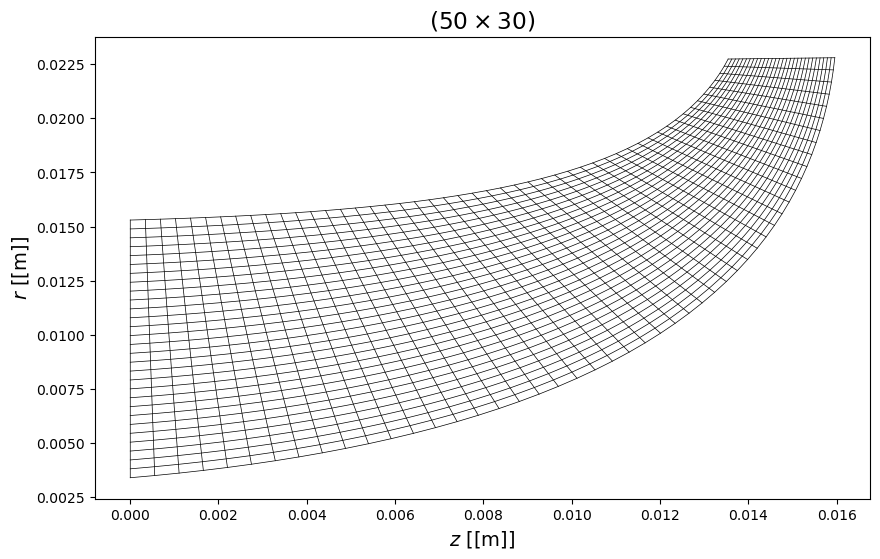

In [2]:
# compute the bladed domain block object
data_folder_path = '../../Grid/geo/'
units = '[m]'
nstream = 50
nspan = 30
grid_sampling = 'default'
hub = Grid.src.Curve(curve_filepath=data_folder_path + 'iris_hub.curve', units=units, degree_spline=3)
shroud = Grid.src.Curve(curve_filepath=data_folder_path + 'iris_shroud.curve', units=units, degree_spline=3)
bladed_block = Grid.src.Block(hub, shroud, blade_file=data_folder_path + 'iris_blade.curve', block_type='blade',
                     nstream=nstream, nspan=nspan)

# compute the blade object info, in order to cut the block appropriately
blade = Grid.src.Blade(data_folder_path + 'iris_blade.curve')
blade.find_inlet_points()
blade.find_outlet_points()

# cut the bladed block properly, and compute the meridional structured mesh
bladed_block.add_inlet_outlet_curves(blade.inlet, blade.outlet)
bladed_block.extend_inlet_outlet_curves()
bladed_block.find_intersections()
bladed_block.bladed_zone_trim()
bladed_block.spline_of_trim()
bladed_block.sample(sampling_mode = grid_sampling)
bladed_block.compute_span_points(sampling_mode = grid_sampling)
bladed_block.compute_double_grid()
bladed_block.find_border()
bladed_block.plot_full_grid(save_filename='grid_%2d_%2d' % (nstream, nspan))

# find the camber surface, using the (z,r) grid found in the bladed block
blade.find_camber_surface(bladed_block)
blade.compute_camber_vectors()

# instantiate cfd data object and perform processing removing the outliers
file_name = '../data/iris_85krpm_0.11kgs.csv'
data = Grid.src.CfdData(file_name, rpm_shaft=+85e3, cut_block=bladed_block, blade=blade, verbose=True)
data.process_from_ansys_csv()
data.compute_flow_ideal_vectors()
data.compute_bfm_radial_fields()

# Case 1
- adapted grid
- circular circumferential averaging
- borders not fixed
- gauss filter not active

performing circumferential averages...


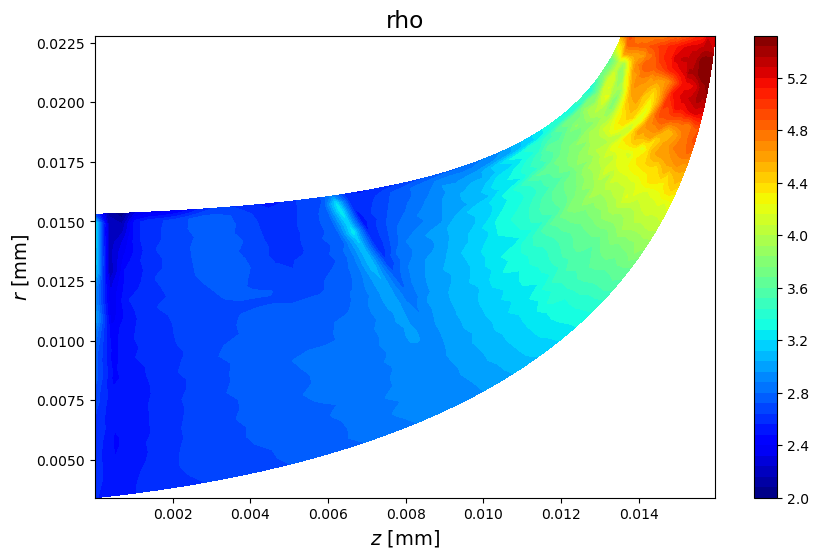

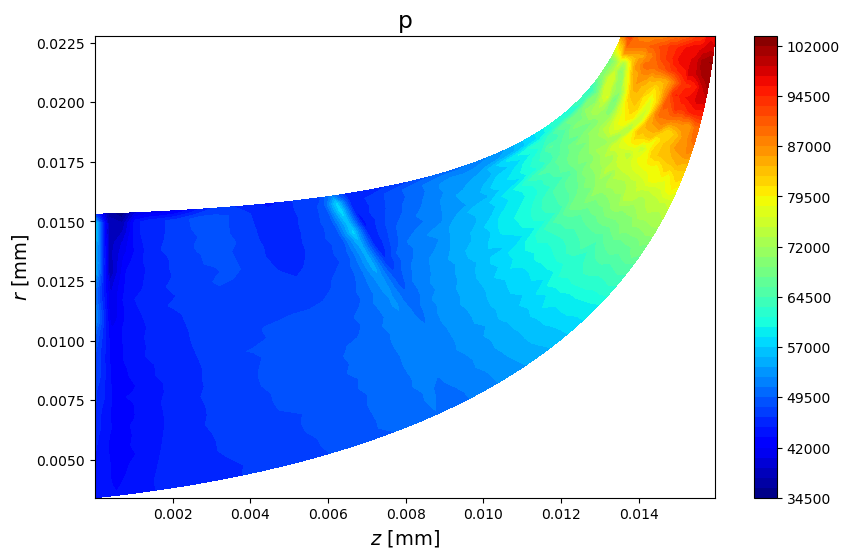

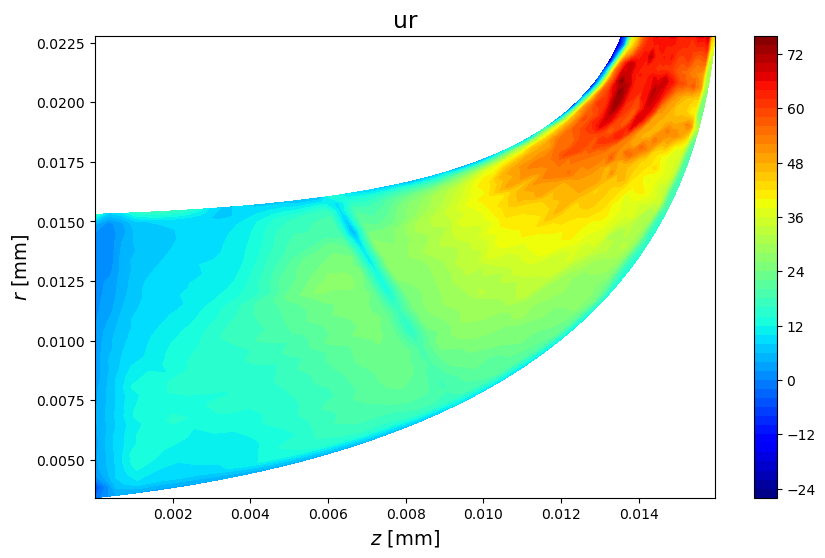

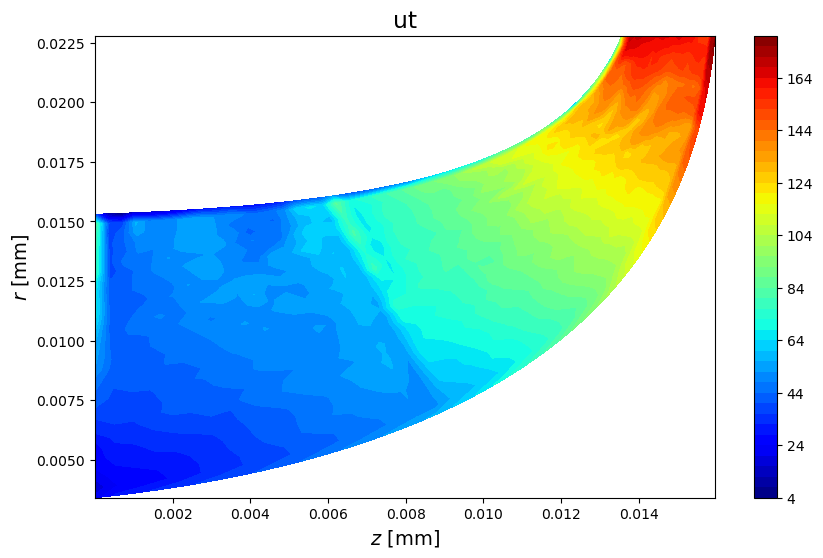

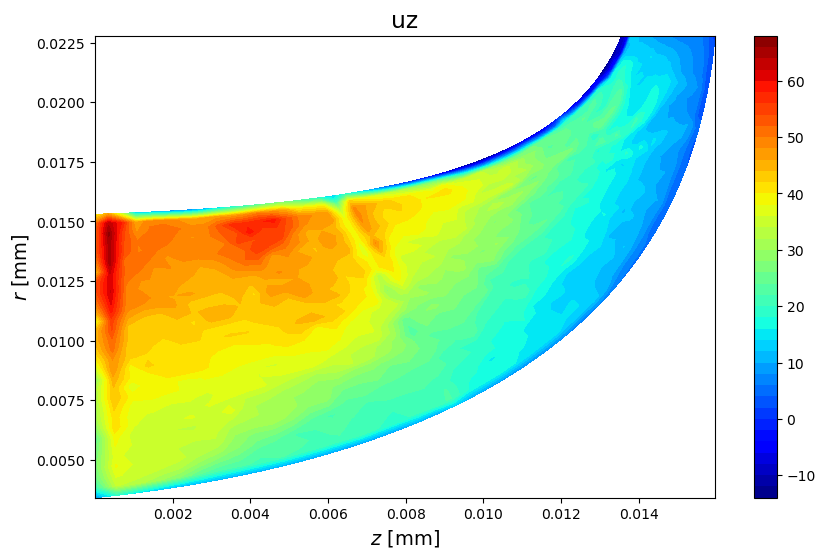

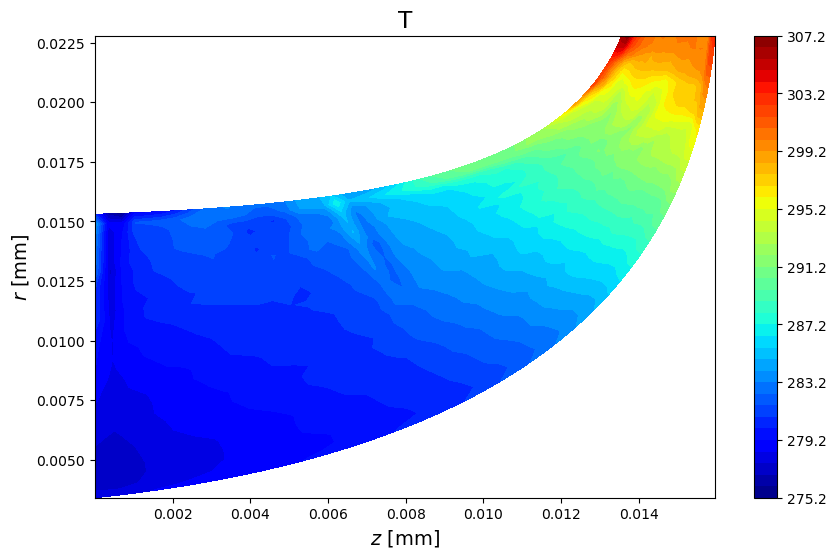

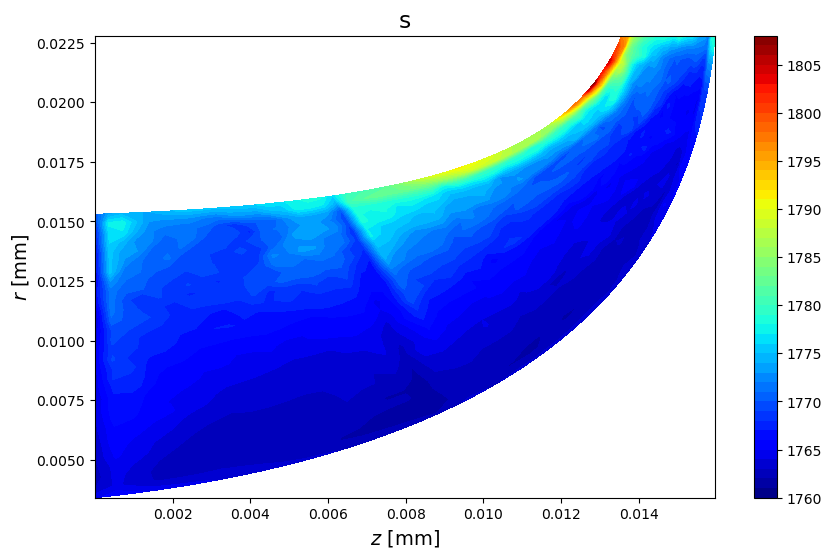

In [3]:
data_process = Grid.src.MeridionalProcess(data, block=bladed_block, blade=blade, verbose=True)
data_process.circumferential_average(mode='circular', bfm = 'radial', fix_borders=False, gauss_filter=False)
data_process.contour_plot(field='rho')
data_process.contour_plot(field='p')
data_process.contour_plot(field='ur')
data_process.contour_plot(field='ut')
data_process.contour_plot(field='uz')
data_process.contour_plot(field='T')
data_process.contour_plot(field='s')

# Case 2
- adapted grid
- circular circumferential averaging
- borders fixed
- gauss filter not active

performing circumferential averages...


/Users/fneri/Documents/PhD/Unsflow/Grid/notebooks/../../Grid/src/meridional_process.py:900: RuntimeWarning: invalid value encountered in double_scalars
  self.mu[istream, ispan] = (ptot_b - ptot_a) / (rho_a * (s_b - s_a) * V_a ** 2)


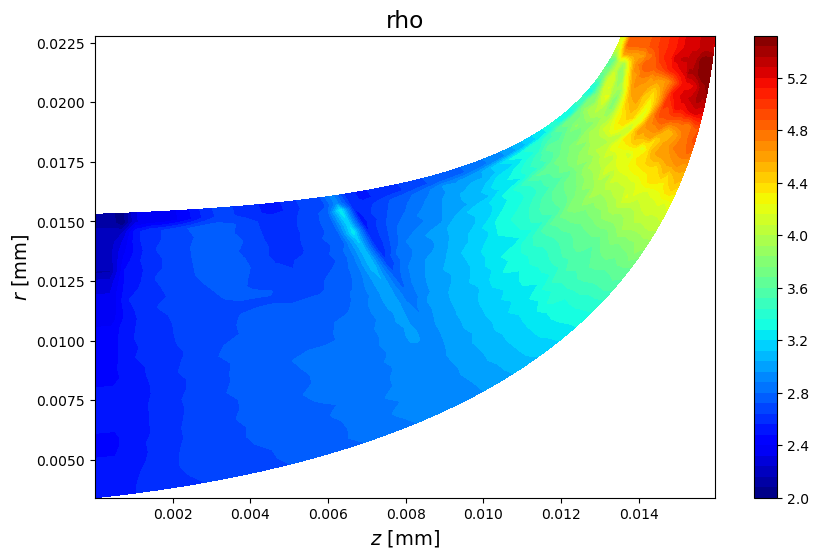

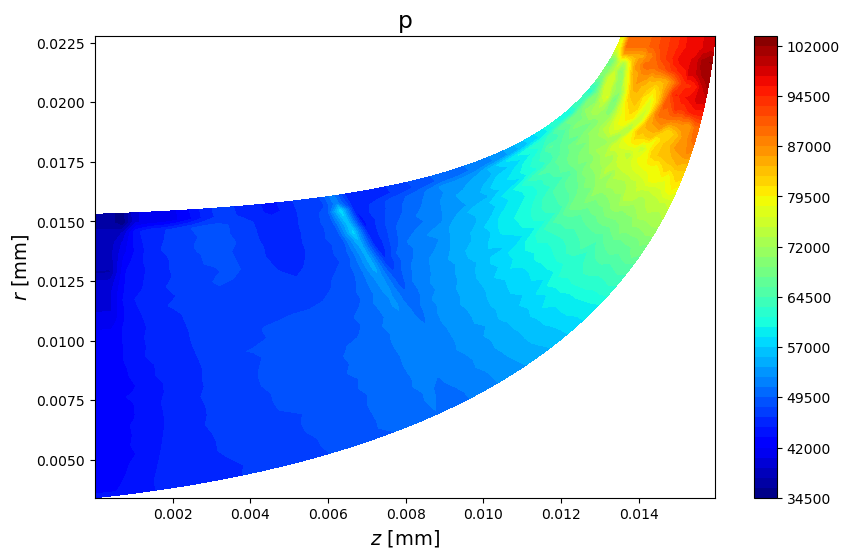

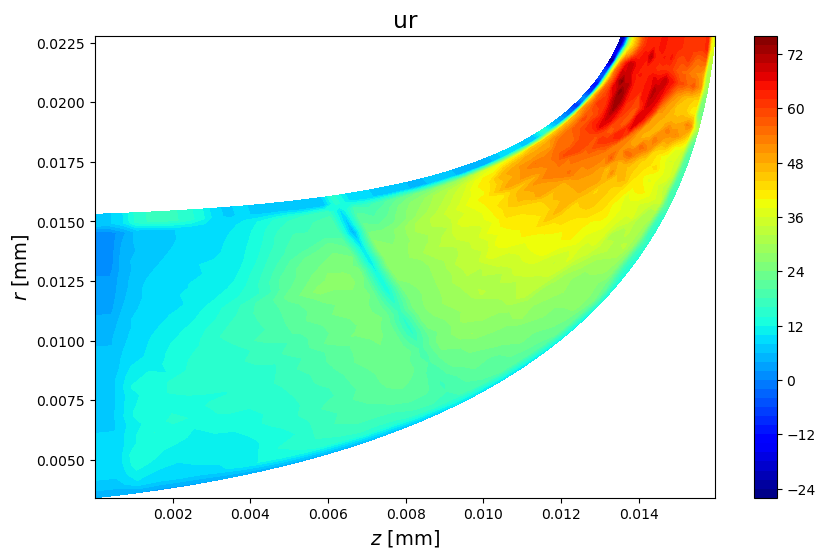

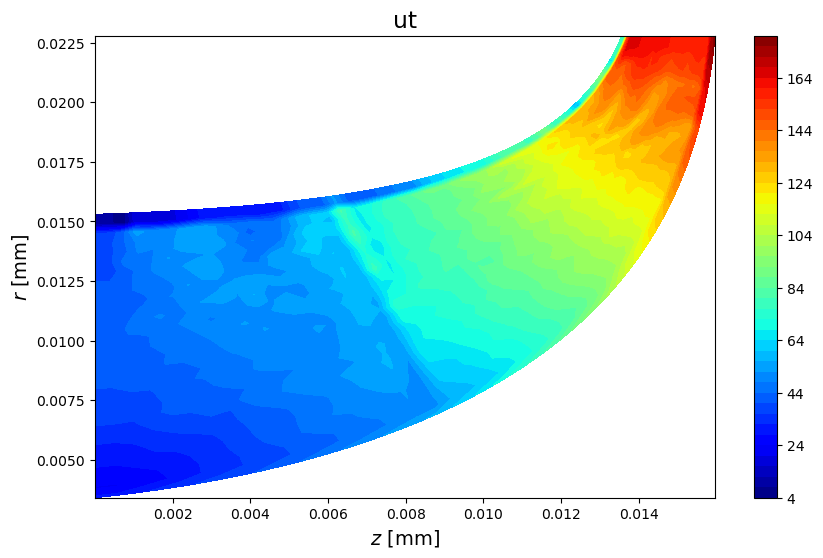

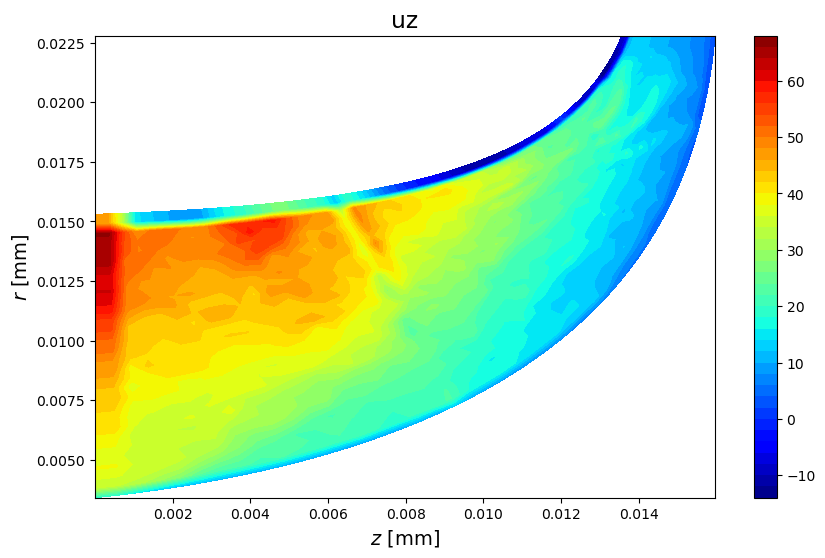

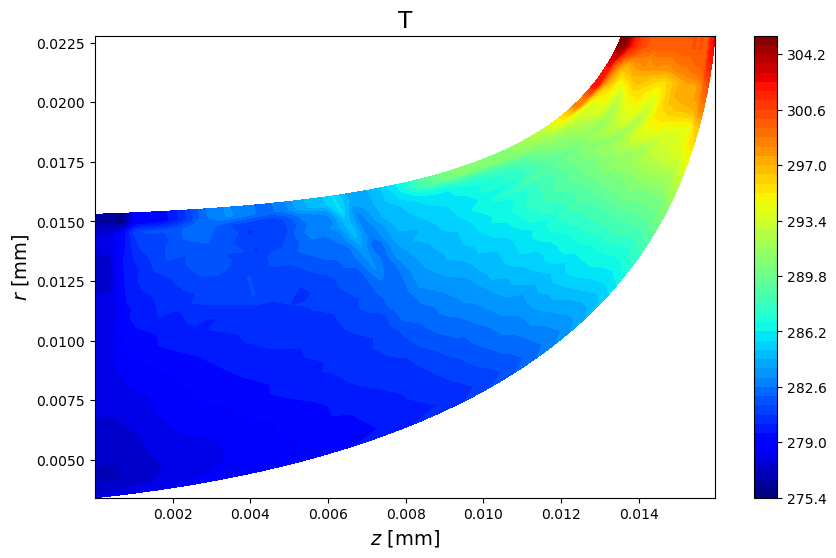

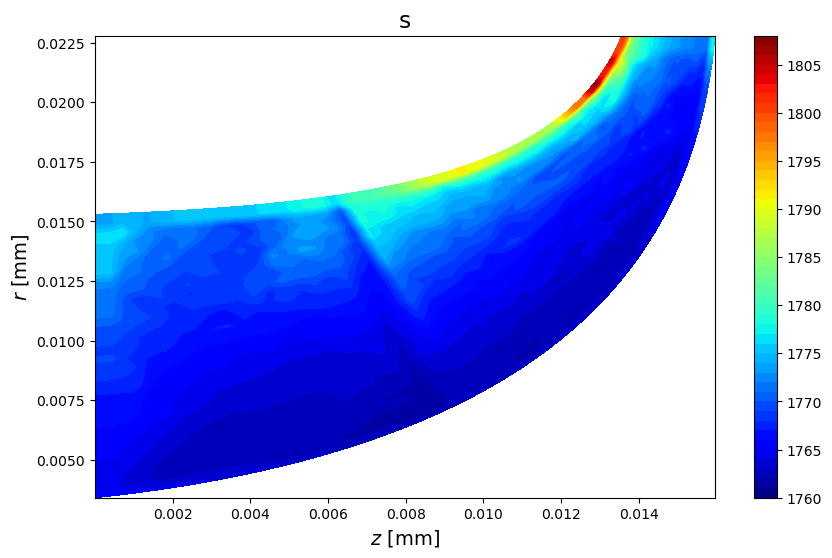

In [4]:
data_process = Grid.src.MeridionalProcess(data, block=bladed_block, blade=blade, verbose=True)
data_process.circumferential_average(mode='circular', bfm = 'radial', fix_borders=True, gauss_filter=False)
data_process.contour_plot(field='rho')
data_process.contour_plot(field='p')
data_process.contour_plot(field='ur')
data_process.contour_plot(field='ut')
data_process.contour_plot(field='uz')
data_process.contour_plot(field='T')
data_process.contour_plot(field='s')

# Case 3
- adapted grid
- circular circumferential averaging
- borders not fixed
- gauss filter active

performing circumferential averages...


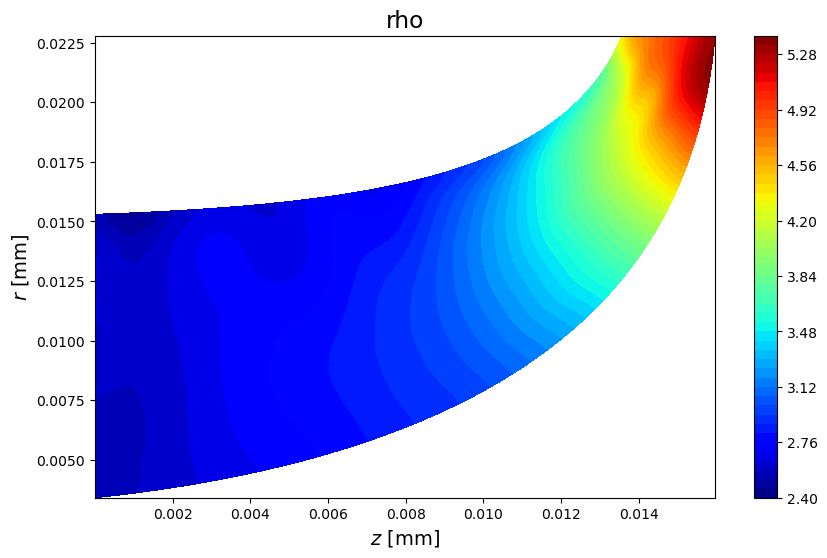

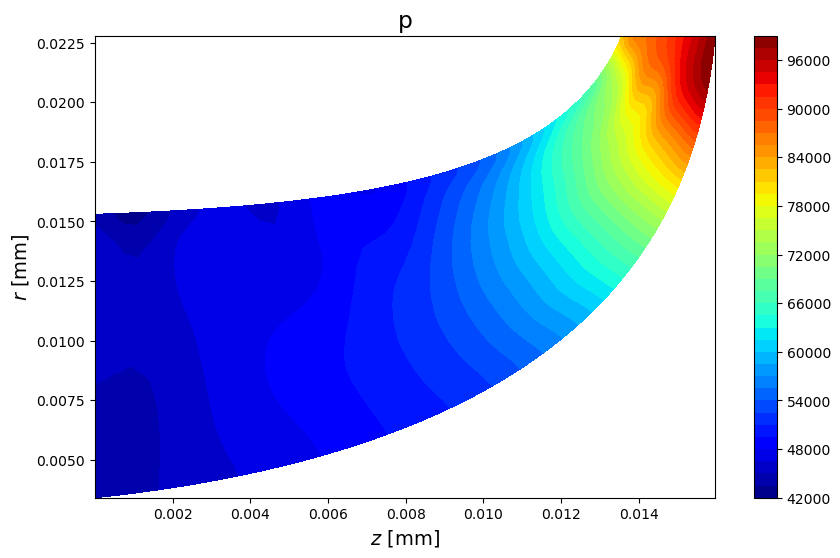

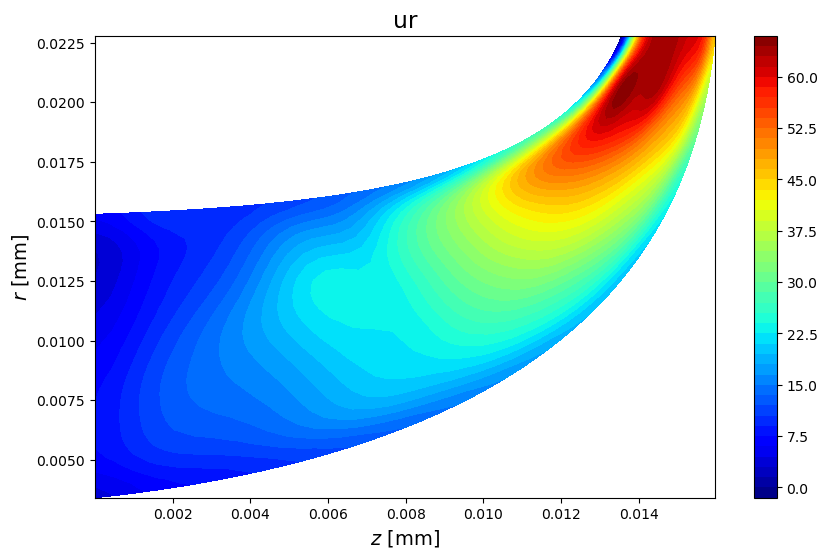

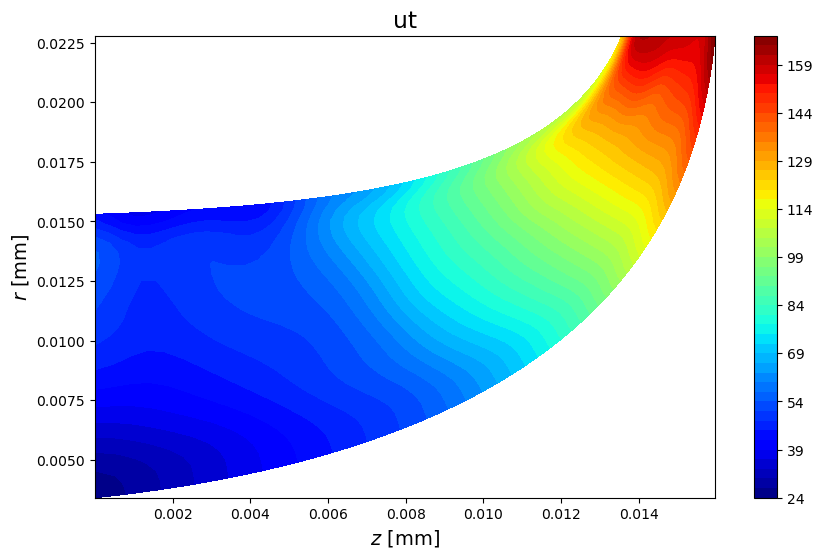

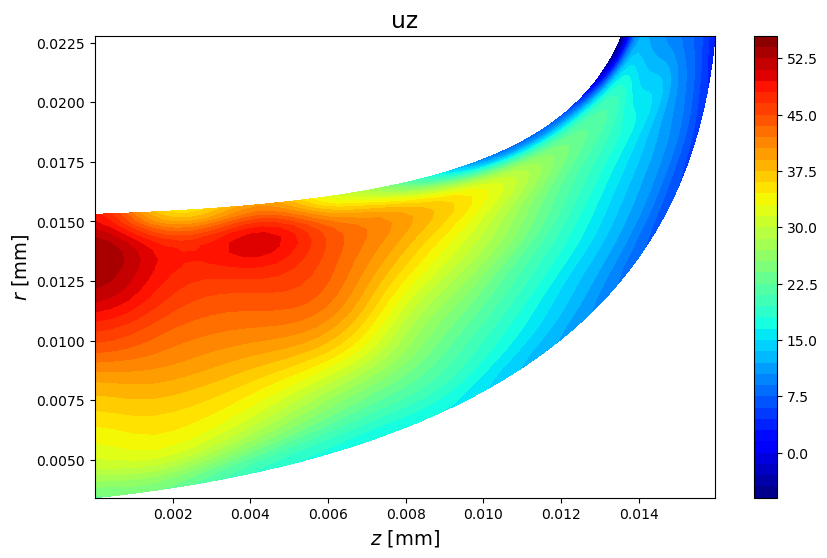

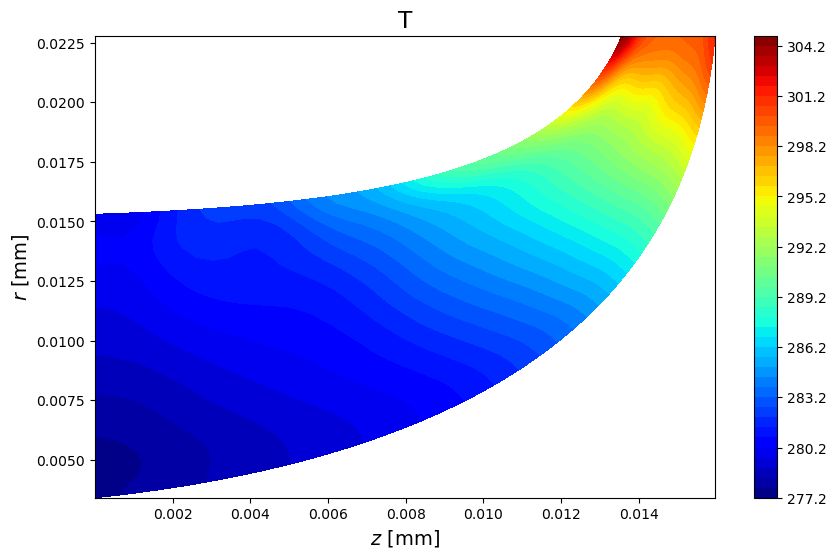

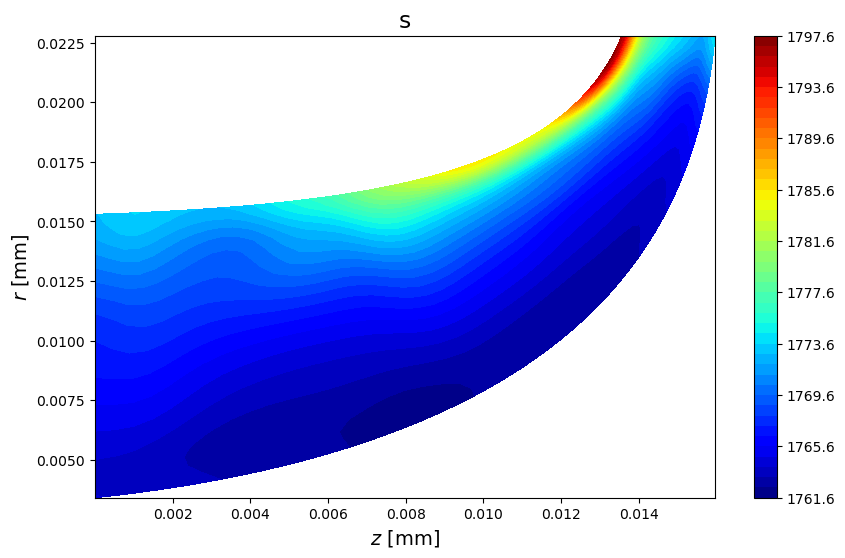

In [5]:
data_process = Grid.src.MeridionalProcess(data, block=bladed_block, blade=blade, verbose=True)
data_process.circumferential_average(mode='circular', bfm = 'radial', fix_borders=False, gauss_filter=True)
data_process.contour_plot(field='rho')
data_process.contour_plot(field='p')
data_process.contour_plot(field='ur')
data_process.contour_plot(field='ut')
data_process.contour_plot(field='uz')
data_process.contour_plot(field='T')
data_process.contour_plot(field='s')

# Case 4
- adapted grid
- circular circumferential averaging
- borders fixed
- gauss filter active

performing circumferential averages...


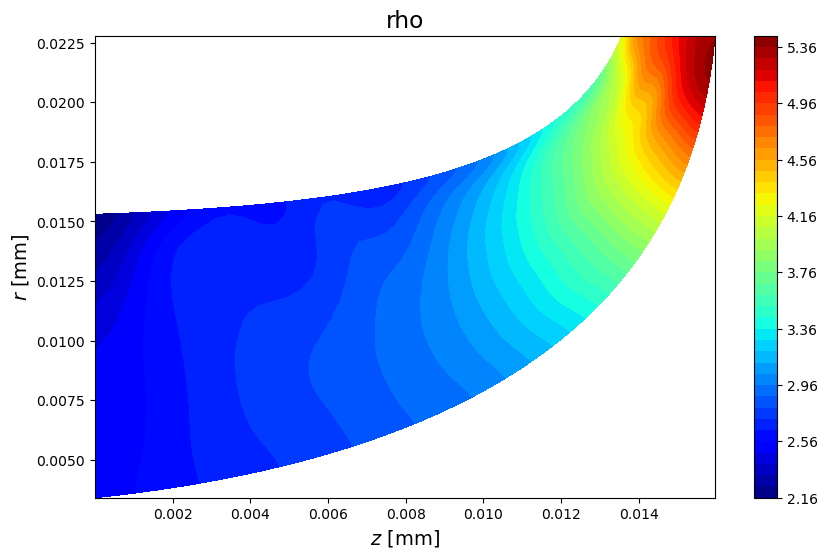

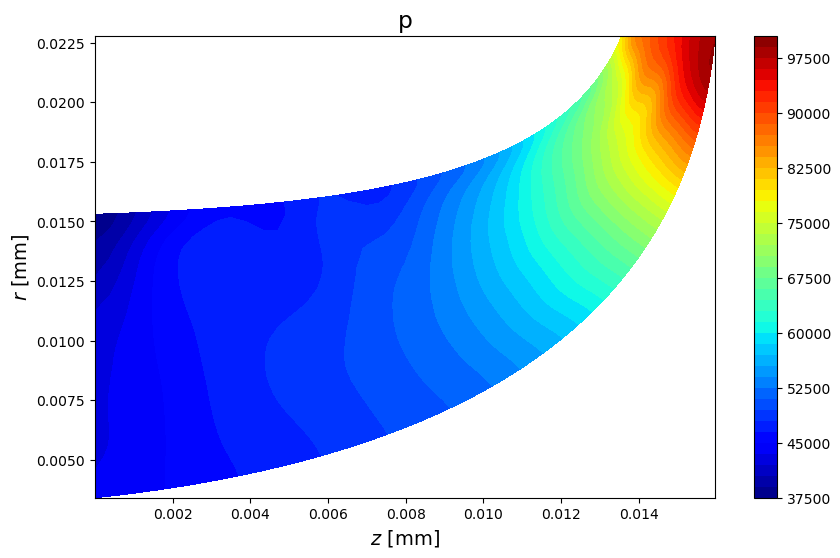

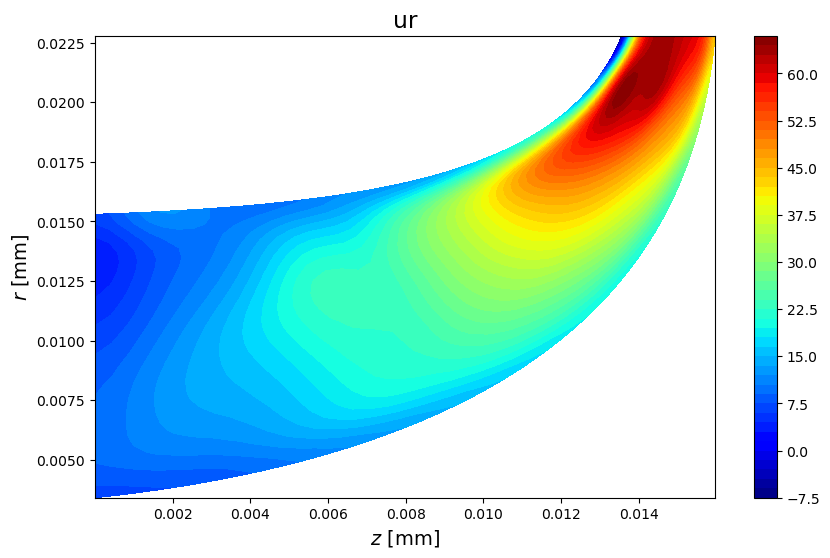

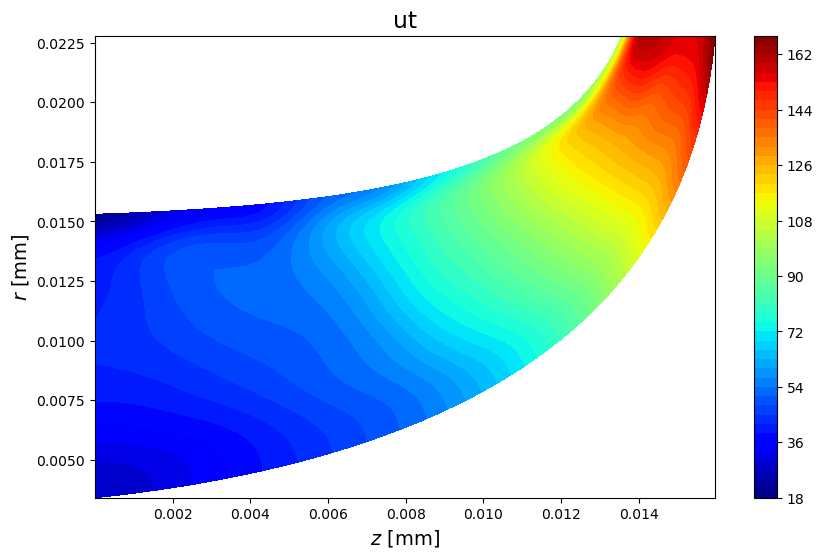

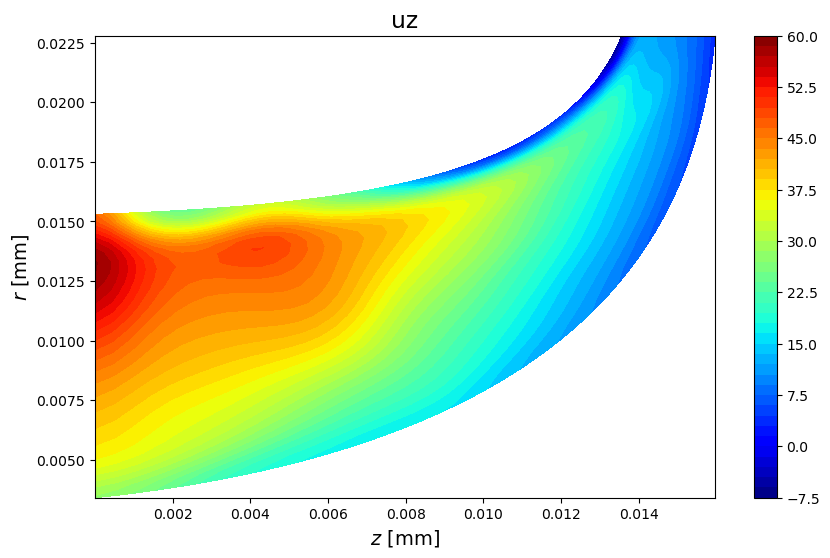

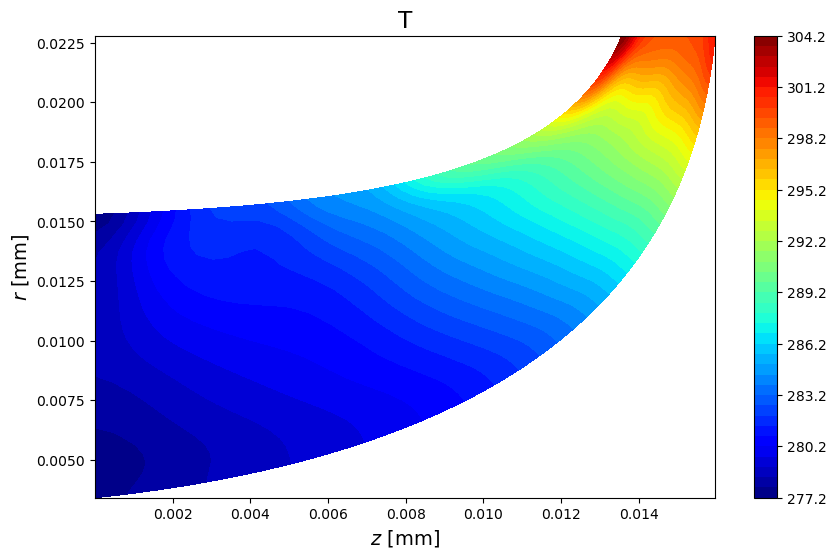

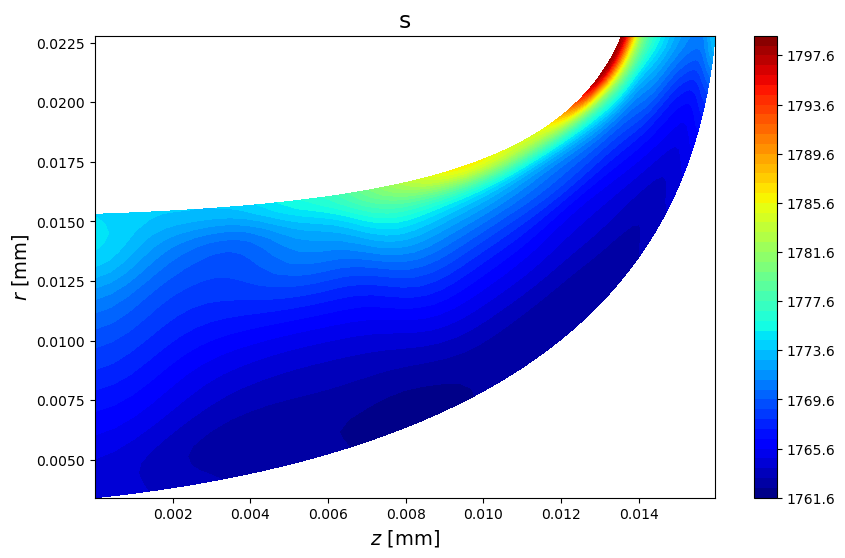

In [6]:
data_process = Grid.src.MeridionalProcess(data, block=bladed_block, blade=blade, verbose=True)
data_process.circumferential_average(mode='circular', bfm = 'radial', fix_borders=True, gauss_filter=True)
data_process.contour_plot(field='rho')
data_process.contour_plot(field='p')
data_process.contour_plot(field='ur')
data_process.contour_plot(field='ut')
data_process.contour_plot(field='uz')
data_process.contour_plot(field='T')
data_process.contour_plot(field='s')